# Diversification in the S&P 500

## Summary

The S&P 500 is treated as the benchmark of passive diversification. Over the past decade, a small group of mega-cap technology firms has grown fast enough to raise a question: does the index still spread risk, or has it become a bet on a few companies?

We look at *concentration risk* over a ten-year window by comparing three portfolios:

1. The S&P 500, weighted by market capitalization.
2. The S&P 500 Equal Weight, where each of the 500 constituents gets 0.2%.
3. The "Magnificent Seven" portfolio, an equal-weight basket of seven large technology firms (Microsoft, Apple, Nvidia, Amazon, Alphabet, Meta, Tesla).

## 1. Data loading

- All calculations live in reusable Python functions so the analysis can be rerun.
- When assets from different markets are combined, holiday calendars do not always line up. A forward-fill (`.ffill()`) carries the last available price forward, then `.dropna()` drops any rows left unmatched at the start.
- Core libraries: `matplotlib`, `numpy`, `pandas`, `yfinance`, `fredapi`, `scipy`.

In [52]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from dotenv import load_dotenv
from fredapi import Fred
from scipy import stats


def data_download(
    tickers_name: dict,
    start_date: str = "2016-01-01",
    end_date: str = "2026-01-01",
) -> pd.DataFrame:
    """
    Downloads closing prices from Yahoo Finance.
    """
    tickers = list(tickers_name)
    data = yf.download(tickers, start=start_date, end=end_date)
    data = data["Close"].rename(columns=tickers_name).ffill().dropna()  # type: ignore
    return data


def rolling_volatility(
    daily_log_return: pd.DataFrame, window: int = 252
) -> pd.DataFrame:
    """
    Calculates rolling annualized volatility over a moving window.
    """
    rolling_volatility_df = daily_log_return.rolling(window).std() * np.sqrt(252)
    return rolling_volatility_df.dropna()


def return_hist(asset_daily_log_return: pd.Series) -> None:
    """
    Plots the empirical histogram of daily returns.
    """
    asset_name = asset_daily_log_return.name
    plt.hist(
        asset_daily_log_return,
        bins="fd",
        density=True,
        label=f"{asset_name} return",
    )
    plt.xlabel("Daily return")
    plt.ylabel("Density")


def normal_comparison(asset_daily_log_return: pd.Series) -> None:
    """
    Plots the empirical histogram of daily returns comparing to a normal distribution.
    """
    mu = asset_daily_log_return.mean()
    sigma = asset_daily_log_return.std()
    asset_name = asset_daily_log_return.name
    return_hist(asset_daily_log_return)
    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
    y = stats.norm.pdf(x, loc=mu, scale=sigma)
    plt.plot(x, y, label="Normal distribution")
    plt.title(f"{asset_name} vs. normal distribution")
    plt.legend()
    plt.show()
    plt.close()


def return_qq_plot(asset_daily_log_return: pd.Series) -> None:
    """
    Plots a Q-Q Plot comparing the empirical returns to a normal distribution.
    """
    asset_name = asset_daily_log_return.name
    stats.probplot(asset_daily_log_return, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {asset_name} vs. normal distribution")
    plt.grid(True)
    plt.show()
    plt.close()


def student_comparison(asset_daily_log_return: pd.Series) -> np.float64:
    """
    Plots the empirical histogram of daily returns comparing to a t-distribution,
    returns the fitted degrees of freedom.
    """
    mu = asset_daily_log_return.mean()
    sigma = asset_daily_log_return.std()
    asset_name = asset_daily_log_return.name
    return_hist(asset_daily_log_return)
    nu, t_loc, t_scale = stats.t.fit(asset_daily_log_return)
    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
    y = stats.t.pdf(x, df=nu, loc=t_loc, scale=t_scale)
    plt.plot(x, y, label="t-distribution")
    plt.title(f"{asset_name} vs. t-distribution")
    plt.legend()
    plt.show()
    plt.close()
    return round(nu, 2)


def excess_return(
    daily_simple_return: pd.DataFrame,
    daily_risk_free_rate: pd.DataFrame,
) -> pd.DataFrame:
    """
    Calculates excess return for each asset, on the asset trading calendar.
    """
    daily_risk_free_rate_series = (
        daily_risk_free_rate.iloc[:, 0].reindex(daily_simple_return.index).ffill()
    )
    excess_return_df = daily_simple_return.sub(daily_risk_free_rate_series, axis=0)
    return excess_return_df


def sharpe_ratio(
    daily_simple_return: pd.DataFrame,
    daily_risk_free_rate: pd.DataFrame,
) -> pd.DataFrame:
    """
    Calculates annualized Sharpe Ratio.
    """
    excess_return_df = excess_return(daily_simple_return, daily_risk_free_rate)
    sharpe_ratio = excess_return_df.mean() / excess_return_df.std() * np.sqrt(252)
    return pd.DataFrame(sharpe_ratio, columns=["Annualized Sharpe ratio"])


def rolling_sharpe_ratio(
    daily_simple_return: pd.DataFrame,
    daily_risk_free_rate: pd.DataFrame,
    window: int = 63,
) -> pd.DataFrame:
    """
    Calculates rolling annualized Sharpe Ratio over a moving window.
    """
    excess_return_df = excess_return(daily_simple_return, daily_risk_free_rate)
    rolling_sharpe_ratio = (
        excess_return_df.rolling(window).mean()
        / excess_return_df.rolling(window).std()
        * np.sqrt(252)
    )
    return rolling_sharpe_ratio.dropna()


def sortino_ratio(
    daily_simple_return: pd.DataFrame,
    daily_risk_free_rate: pd.DataFrame,
    mar: float = 0,
) -> pd.DataFrame:
    """
    Calculates annualized Sortino Ratio.
    """
    excess_return_df = excess_return(daily_simple_return, daily_risk_free_rate)
    downside_deviation = np.sqrt(((excess_return_df - mar).clip(upper=0) ** 2).mean())
    sortino_ratio = excess_return_df.mean() / downside_deviation * np.sqrt(252)
    return pd.DataFrame(sortino_ratio, columns=["Annualized Sortino ratio"])


def max_drawdown(daily_simple_return: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates maximum drawdown.
    """
    compounded_return = (1 + daily_simple_return).cumprod()
    drawdown = compounded_return / compounded_return.cummax() - 1
    return pd.DataFrame(drawdown.min(), columns=["Max drawdown"])


def hhi(weights: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates Herfindahl-Hirschman Index and the Effective Number of Constituents.
    """
    hhi_value = (weights["Weight"] ** 2).sum(axis=0) * 10_000
    enc = 10_000 / hhi_value
    return pd.DataFrame([hhi_value, enc], index=["HHI", "ENC"], columns=["Value"])

### 1.1 Data gathering and preprocessing

We keep only the `Close` prices. SPY, RSP, and the seven Magnificent Seven stocks share the same US equity holiday calendar, so there are no missing dates. We still apply `.ffill().dropna()` as a safeguard. The U.S. 3-Month Treasury Bill, pulled from the FRED API, is used later as the *risk-free rate* for the Sharpe and Sortino ratios.

Three datasets are downloaded: `sp_500`, `sp_500_ew`, and `mag_seven_stocks` (AAPL, MSFT, NVDA, AMZN, GOOGL, META, TSLA).

In [53]:
sp_500 = data_download({"SPY": "S&P 500"})
sp_500_ew = data_download({"RSP": "S&P 500 Equal Weight"})
mag_seven_stocks = data_download({
    "MSFT": "Microsoft",
    "AAPL": "Apple",
    "NVDA": "Nvidia",
    "AMZN": "Amazon",
    "GOOGL": "Alphabet",
    "META": "Meta",
    "TSLA": "Tesla",
})

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  7 of 7 completed


## 2. Daily return and portfolio

### 2.1 Simple daily returns

The stock price at time $t$ is $S_t$. The simple daily return is:

$$R_t = \frac{S_t - S_{t-1}}{S_{t-1}}$$

In pandas: `.pct_change().dropna()`.

*All returns below are price returns: dividends are not included. The three portfolios are measured on the same basis, so the comparisons stay fair. Any quoted compounded return is a price return only.*

A portfolio's simple return is the weighted average of its assets' returns. For $M$ assets with weights $w_i$:

$$R_{p,t} = \sum_{i=1}^M w_i R_{i,t}$$

For our equally weighted Magnificent Seven portfolio ($w_i = \frac{1}{7}$):

$$R_{p,t} = \frac{1}{7} \sum_{i=1}^7 R_{i,t}$$

### 2.2 Logarithmic daily returns

The log return is defined as:

$$r_t = \ln\left(\frac{S_t}{S_{t-1}}\right) = \ln(S_t) - \ln(S_{t-1})$$

In pandas: `np.log(asset).diff().dropna()`.

Summing daily log returns gives the cumulative log return over time (a *telescoping sum*):

$$\sum_{t=1}^T r_t = \sum_{t=1}^T (\ln(S_t) - \ln(S_{t-1})) = \ln(S_T) - \ln(S_0)$$

### 2.3 Portfolio synthesis

$$r_t = \ln(1 + R_t) \iff R_t = e^{r_t} - 1$$

Log returns add over time but not across assets. A portfolio's log return is not the average of its assets' log returns:

$$\ln\left( \frac{1}{M} \sum_{i=1}^M e^{r_{i,t}} \right) \ne \frac{1}{M} \sum_{i=1}^M r_{i,t}$$

To build the Magnificent Seven portfolio we:

1. Compute the daily simple returns of the seven stocks.
2. Take the arithmetic mean (`.mean(axis=1)`) to get the portfolio simple return $R_{p,t}$.
3. Convert to log return ($r_{p,t} = \ln(1 + R_{p,t})$) when we need time additivity.

*`.mean(axis=1)` collapses the columns into a 1D Series. We turn it back into a DataFrame before concatenation.*

In [54]:
mag_seven_portfolio_daily_simple_return = (
    mag_seven_stocks.pct_change().dropna().mean(axis=1)
)
mag_seven_portfolio_daily_log_return = np.log(
    1 + mag_seven_portfolio_daily_simple_return
)

### 2.4 Asset merging

The three log-return series are merged into one dataset named `every_daily_log_return`.

#### Method

- `pd.concat(..., axis=1)` aligns the indexes automatically across the three series.
- `.to_frame("Magnificent Seven")` turns the portfolio Series back into a named column before concatenation.

In [55]:
every_daily_log_return = pd.concat(
    [
        np.log(sp_500).diff().dropna(),  # type: ignore
        np.log(sp_500_ew).diff().dropna(),  # type: ignore
        mag_seven_portfolio_daily_log_return.to_frame("Magnificent Seven"),  # type: ignore
    ],
    axis=1,
)
every_daily_log_return.tail().style.format("{:.2%}")

,S&P 500,S&P 500 Equal Weight,Magnificent Seven
Date,,,
2025-12-24 00:00:00,0.35%,0.36%,0.12%
2025-12-26 00:00:00,-0.01%,0.03%,-0.29%
2025-12-29 00:00:00,-0.36%,-0.17%,-0.77%
2025-12-30 00:00:00,-0.12%,-0.16%,-0.04%
2025-12-31 00:00:00,-0.74%,-0.86%,-0.68%


The final dataset holds 2513 days. The raw prices cover 2514 trading days. A log return needs a one-day lag, so the first day becomes `NaN` and is dropped, leaving 2513 rows. SPY, RSP, and the seven stocks all trade on US exchanges with the same holiday calendar, so there are no gaps across the columns.

## 3. Historical and rolling volatility

### 3.1 Historical volatility

We define the historical volatility over the full 10-year sample.

- Sample size: $M = 2513$ daily returns.
- Annualization factor: $N = 252$ trading days per year.
- Daily log return: $r_t = \ln(S_t) - \ln(S_{t-1})$.

Empirical mean:

$$\overline{r} = \frac{1}{M} \sum_{t=1}^M r_t$$

Empirical daily variance with Bessel's correction:

$$s^2 = \frac{1}{M-1} \sum_{t=1}^M (r_t - \overline{r})^2$$

*The true population mean is unknown, so we estimate it with $\overline{r}$. Because $\overline{r}$ is built from the same data, the observations sit closer to $\overline{r}$ than to the true mean. Dividing by $M$ would underestimate the variance, so we divide by $M-1$.*

Daily volatility:

$$s = \sqrt{\frac{1}{M-1} \sum_{t=1}^M (r_t - \overline{r})^2}$$

*$s^2$ is an unbiased estimator of $\sigma^2$, but $s$ is a biased estimator of $\sigma$ (Jensen's inequality, since the square root is strictly concave). We keep the standard $M-1$ correction, which is pandas' default.*

Annualized volatility:

$$s_{\text{annualized}} = s \times \sqrt{252}$$

Assuming daily log returns are independent and identically distributed:

$$\operatorname{Var}(r_{\text{annualized}}) = \operatorname{Var}\left( \sum_{t=1}^{252} r_t \right) = \sum_{t=1}^{252} \operatorname{Var}(r_t) = 252 \times s^2$$

In [56]:
vol_summary = pd.DataFrame({
    "Daily Volatility": every_daily_log_return.std(),
    "Annualized Volatility": every_daily_log_return.std() * np.sqrt(252),
})
vol_summary.style.format("{:.2%}")

,Daily Volatility,Annualized Volatility
S&P 500,1.14%,18.05%
S&P 500 Equal Weight,1.17%,18.57%
Magnificent Seven,1.83%,29.00%


The Magnificent Seven portfolio's annualized volatility is about $60\%$ above the S&P 500's. That is the extra risk of holding seven names instead of the broader index.

RSP's slightly higher volatility reflects a *structural tilt*: an equal-weight index gives more weight to mid-sized companies, which historically carry higher volatility than the largest mega-caps.

### 3.2 Rolling volatility

To see volatility clustering across the ten years, we compute a one-year rolling annualized volatility.

- Rolling window: $w = 252$ days.

Rolling mean over the window $\{t-w+1, \dots, t\}$:

$$\overline{r_{t,w}} = \frac{1}{w} \sum_{i=0}^{w-1} r_{t-i}$$

Daily rolling volatility:

$$s_{t,w} = \sqrt{\frac{1}{w-1} \sum_{i=0}^{w-1} (r_{t-i} - \overline{r_{t,w}})^2}$$

Annualized rolling volatility:

$$s_{t,w,\text{annualized}} = s_{t,w} \times \sqrt{252}$$

<Axes: xlabel='Date'>

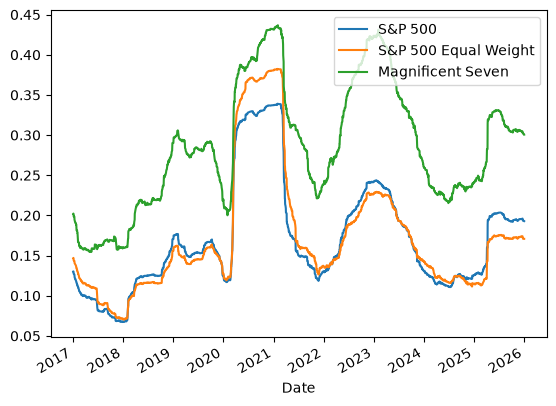

In [57]:
rolling_volatility(every_daily_log_return).plot()

All three portfolios share the same broad risk regimes, most clearly the 2020 spike. The Magnificent Seven stays above the two indices throughout, which confirms that concentration carries higher volatility.

## 4. Correlation matrix

The correlation coefficient measures the strength and direction of the relationship between two assets.

Take the $M = 2513$ centered daily log returns of two assets as column vectors in $\mathbb{R}^M$:

$$\vec{u} = \begin{pmatrix} x_1 - \overline{x} \\ \vdots \\ x_M - \overline{x} \end{pmatrix} \in \mathbb{R}^M, \qquad \vec{v} = \begin{pmatrix} y_1 - \overline{y} \\ \vdots \\ y_M - \overline{y} \end{pmatrix} \in \mathbb{R}^M$$

Dot product:

$$\vec{u} \cdot \vec{v} = \sum_{t=1}^M u_t v_t = \sum_{t=1}^M (x_t - \overline{x})(y_t - \overline{y}) = (M-1) \operatorname{Cov}(X,Y)$$

Norm:

$$\|\vec{u}\| = \sqrt{\sum_{t=1}^M u_t^2} = \sqrt{M-1} \, s_X, \qquad \|\vec{v}\| = \sqrt{M-1} \, s_Y$$

The Pearson correlation coefficient is:

$$r_{xy} = \frac{\sum_{t=1}^M (x_t - \bar{x})(y_t - \bar{y})}{\sqrt{\sum_{t=1}^M (x_t - \bar{x})^2} \sqrt{\sum_{t=1}^M (y_t - \bar{y})^2}} = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \cdot \|\vec{v}\|}$$

By the Cauchy-Schwarz inequality, $|\vec{u} \cdot \vec{v}| \le \|\vec{u}\| \cdot \|\vec{v}\|$. Dividing by the (positive) product of norms shows the correlation is bounded:

$$\left| \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \cdot \|\vec{v}\|} \right| \le 1 \iff -1 \le r_{xy} \le 1$$

So $r_{xy}$ is the cosine of the angle $\theta$ between the two centered vectors:

$$r_{xy} = \cos(\theta)$$

- $\theta = 0^\circ$: vectors aligned, $r_{xy} = 1$ (perfect positive correlation).
- $\theta = 90^\circ$: vectors orthogonal, $r_{xy} = 0$.
- $\theta = 180^\circ$: vectors opposed, $r_{xy} = -1$ (perfect negative correlation).

In [58]:
every_daily_log_return.corr().style.format("{:.2%}")

,S&P 500,S&P 500 Equal Weight,Magnificent Seven
S&P 500,100.00%,94.36%,84.30%
S&P 500 Equal Weight,94.36%,100.00%,68.29%
Magnificent Seven,84.30%,68.29%,100.00%


Despite holding 500 companies, the S&P 500's daily return is $84.30\%$ correlated with a seven-stock tech basket. The index has drifted from a broad market proxy to a bet on a few names.

RSP's correlation with the Magnificent Seven is lower, at $68.29\%$. Capping each constituent at $0.2\%$ ($1.4\%$ combined) cuts the index's dependence on the tech giants.

## 5. Standardized moments, normality and Q-Q plot

### 5.1 Standardized moments and normality

A normal distribution is fully described by its first two moments (mean $\mu$, variance $\sigma^2$). The higher-order *standardized moments* measure how far the empirical returns drift from that baseline.

#### Theoretical population parameters

Skewness measures asymmetry:

$$\gamma_1 = \operatorname{E}\left[ \left( \frac{r_t - \mu}{\sigma} \right)^3 \right]$$

*A symmetric distribution has $\gamma_1 = 0$. Negative skewness means the left tail is longer or heavier than the right.*

Excess kurtosis measures peakedness and tail thickness, normalized to $0$ for the normal distribution:

$$\gamma_2 = \operatorname{E}\left[ \left( \frac{r_t - \mu}{\sigma} \right)^4 \right] - 3$$

*Positive excess kurtosis means a leptokurtic distribution: a sharp central peak, fat tails, and extreme events more often than a normal model predicts.*

#### Unbiased empirical estimators

These match what pandas computes by default with `.skew()` and `.kurt()`:

Unbiased sample skewness:

$$G_1 = \frac{M}{(M-1)(M-2)} \sum_{t=1}^M \left( \frac{r_t - \overline{r}}{s} \right)^3$$

Unbiased sample excess kurtosis:

$$G_2 = \frac{M(M+1)}{(M-1)(M-2)(M-3)} \sum_{t=1}^M \left( \frac{r_t - \overline{r}}{s} \right)^4 - 3\frac{(M-1)^2}{(M-2)(M-3)}$$

The Jarque-Bera test checks whether the series are normally distributed:

$$JB = \frac{M}{6} \left( G_1^2 + \frac{G_2^2}{4} \right)$$

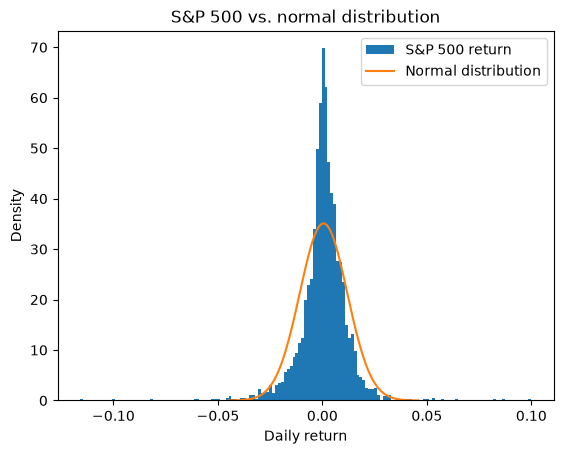

,Skewness,Kurtosis,Jarque-Bera statistic,p-value
S&P 500,-0.60,15.15,24095.56,0.00
S&P 500 Equal Weight,-0.79,16.73,29427.14,0.00
Magnificent Seven,-0.34,5.26,2935.72,0.00


In [59]:
skew_kurt = pd.DataFrame({
    "Skewness": every_daily_log_return.skew(),
    "Kurtosis": every_daily_log_return.kurt(),
})
j_b = (
    pd
    .DataFrame(every_daily_log_return.apply(stats.jarque_bera))
    .set_axis(["Jarque-Bera statistic", "p-value"], axis=0)
    .T
)
normality = pd.concat([skew_kurt, j_b], axis=1)

normal_comparison(every_daily_log_return["S&P 500"])

normality.style.format("{:.2f}")

All three series are left-skewed, which means market crashes fall faster than they recover.

RSP shows the highest *excess kurtosis*. Its 500 averaged daily moves produce a sharp central peak, but joint downside spikes in panics add fat tails. The Magnificent Seven has the lowest excess kurtosis, which runs against the intuition that "more volatile" should mean "more extreme-tailed."

All three JB statistics sit far above the $5.99$ threshold for a $5\%$ significance level (the Jarque-Bera statistic follows a $\chi^2_2$ distribution), with p-values near zero. We reject the null hypothesis of normality for all three return series.

A normal distribution would predict extreme daily moves of at most about $\pm 4\%$ (see the Q-Q plot below). In practice that does not hold.

That is why the claim "volatility captures all the risk" is misleading. Volatility measures the width of the return distribution, its typical daily move. Risk is the probability of losing money, the mass in the left tail. Under a normal distribution the two carry the same information: the curve is determined by its mean and standard deviation, so knowing both gives every probability, including the extreme ones. When the tails are fat, that link breaks. Volatility still describes the typical day, but it says little about how often the worst days occur. That is what makes the non-normality result practically relevant, beyond the statistical rejection.

### 5.2 Q-Q plot

The histogram shows the extreme central peak (leptokurtosis) of the S&P 500's returns but compresses the tails against the horizontal axis, which makes extreme events hard to read. A Q-Q plot fixes this by plotting the sorted empirical quantiles of the S&P 500 (y-axis) against the theoretical quantiles of a normal distribution (x-axis).

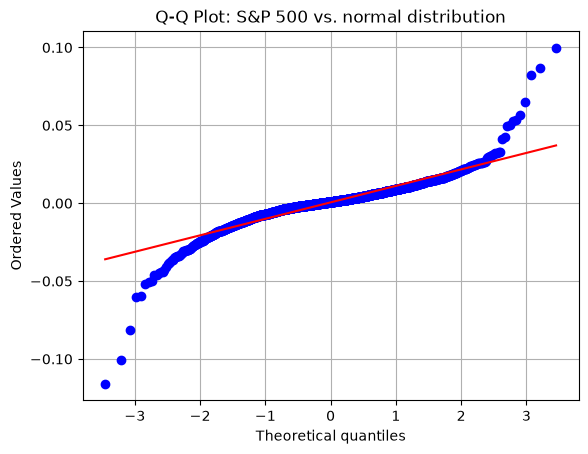

In [60]:
return_qq_plot(every_daily_log_return["S&P 500"])

- Center ($-1.5$ to $+1.5\sigma$): points sit close to the diagonal reference line on ordinary trading days, so the normal model is a reasonable approximation.
- Left tail: below $-2\sigma$, points drop away. The worst single-day loss in the sample is around $-11\%$ to $-12\%$, against roughly $-4.0\%$ predicted by the normal model.
- Right tail: above $+2\sigma$, points lift away, reaching about $+10.0\%$ against a normal-model ceiling near $+4.0\%$.

The resulting S-curve is the sign of fat tails: extreme moves happen far more often than the normal model predicts.

### 5.3 Student's t-distribution

Because the normal distribution underestimates extreme moves, we fit the Student's t-distribution instead. The t-distribution has an extra parameter, the *degrees of freedom* $\nu$, which controls tail thickness.

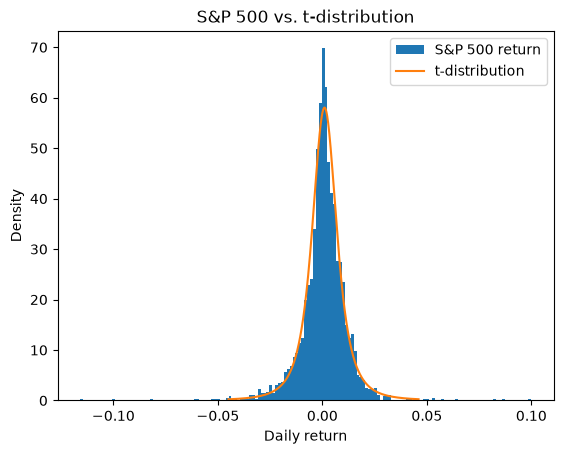

np.float64(2.55)

In [61]:
student_comparison(every_daily_log_return["S&P 500"])

Fitting the Student's t-distribution to the S&P 500 returns by *maximum likelihood* (`stats.t.fit`) gives $\nu \approx 2.55$.

The fitted t-distribution (orange) tracks the empirical histogram more closely than the normal curve did, especially in the tails. A low $\nu$ means the tails are much heavier than a normal distribution allows, which lines up with the excess kurtosis and Jarque-Bera results above.

## 6. Sharpe ratio

The Sharpe ratio measures *excess return* per unit of volatility.

Instead of a constant risk-free rate, we use the historical yield of the U.S. 3-Month Treasury Bill from the FRED API, which moves over time.

In [62]:
load_dotenv()
fred = Fred(api_key=os.getenv("FRED_API_KEY"))
rate = fred.get_series(
    "DGS3MO", observation_start="2016-01-01", observation_end="2026-01-01"
)
risk_free_rate = pd.DataFrame(rate).ffill().dropna() / 100

daily_risk_free_rate = (1 + risk_free_rate) ** (1 / 252) - 1
daily_risk_free_rate.shape

(2609, 1)

### 6.1 Static Sharpe ratio

We use simple returns for the Sharpe ratio.

Daily excess return:

$$R^e_t = R_t - R^f_t$$

Daily Sharpe ratio:

$$\text{Sharpe}_{\text{daily}} = \frac{\overline{R^e}}{s(R^e)}$$

Annualized Sharpe ratio:

$$\text{Sharpe} = \sqrt{252} \times \frac{\overline{R^e}}{s(R^e)}$$

Annualizing turns one day into one year: the mean return is multiplied by $252$, the standard deviation by $\sqrt{252}$. The mean grows linearly because a steady gain adds up day after day in the same direction. Expected annual excess return:

$$\operatorname{E}[R^e_{\text{annual}}] = \operatorname{E}\left[ \sum_{t=1}^{252} R^e_t \right] = 252 \times \operatorname{E}[R^e]$$

Under independence, the volatility of the sum grows like the square root of the number of days: gains and losses partly cancel each other over time, so the variances add while the standard deviation grows with $\sqrt{252}$. Annual volatility:

$$s(R^e_{\text{annual}}) = \sqrt{252} \times s(R^e)$$

Substituting both into the annual ratio:

$$\text{Sharpe} = \frac{252 \times \operatorname{E}[R^e]}{\sqrt{252} \times s(R^e)} = \sqrt{252} \times \text{Sharpe}_{\text{daily}}$$

In [63]:
every_daily_simple_return = np.exp(every_daily_log_return) - 1

sharpe_ratio(every_daily_simple_return, daily_risk_free_rate).style.format("{:.2f}")

,Annualized Sharpe ratio
S&P 500,0.74
S&P 500 Equal Weight,0.57
Magnificent Seven,1.16


SPY's Sharpe ratio beats RSP's by roughly $30\%$. Over 2016 to 2025, the largest names grew fast enough to more than offset the lack of diversification their weight implies. So "less diversified" and "worse risk-adjusted performance" are not the same claim.

Despite having the highest volatility of the three, the Magnificent Seven's returns were steady enough to make it the most efficient portfolio over this period.

RSP's lower Sharpe is the cost of its diversification: capping the Magnificent Seven's combined weight near $1.4\%$ cut its exposure to their outsized gains, while the basket still carries the higher baseline volatility of a mid-cap tilt.

### 6.2 Rolling Sharpe ratio

- Rolling window: $w = 63$ trading days

Rolling expected excess return, over $\{t-w+1, \dots, t\}$:

$$\overline{R^e_{t, w}} = \frac{1}{w} \sum_{i=0}^{w-1} R^e_{t-i}$$

Rolling risk:

$$s_{t,w}(R^e) = \sqrt{\frac{1}{w-1} \sum_{i=0}^{w-1} (R^e_{t-i} - \overline{R^e_{t, w}})^2}$$

Annualized rolling Sharpe:

$$\text{Sharpe}_{t,w,\text{ann}} = \sqrt{252} \times \frac{\overline{R^e_{t, w}}}{s_{t,w}(R^e)}$$

*The excess returns are computed on the asset trading calendar only: the Treasury yields are reindexed onto those dates (a rate level, not a transaction, so a forward fill is valid). Dropping the first $62$ days needed to fill the initial window leaves $2451$ rows ($2513 - 63 + 1$). The rolling series starts on the $63^{\text{rd}}$ trading day, on April 5, 2016.*

In [64]:
rolling_sharpe_ratio(
    every_daily_simple_return, daily_risk_free_rate
).tail().style.format("{:.2f}")

,S&P 500,S&P 500 Equal Weight,Magnificent Seven
Date,,,
2025-12-24 00:00:00,1.38,1.13,1.21
2025-12-26 00:00:00,1.19,0.81,1.02
2025-12-29 00:00:00,0.99,0.64,0.79
2025-12-30 00:00:00,0.83,0.50,0.76
2025-12-31 00:00:00,0.49,0.13,0.55


At the end of the year, an investor in the equal-weighted index was almost at the risk-free rate. An investor in the standard S&P 500 was not.

### 6.3 Sortino ratio

The Sharpe ratio treats gains and losses the same way: a large positive swing lowers the ratio as much as a large negative one.

The Sortino ratio uses *downside deviation* $\sigma_d$ instead of the standard deviation. It only counts returns below a Minimum Acceptable Return (MAR).

Here $\text{MAR} = 0$: we penalize only daily excess returns below the dynamic risk-free rate ($R^e_t < 0$).

Theoretical downside variance:

$$\sigma_d^2 = \operatorname{E}\left[ \min(R^e - \text{MAR}, \, 0)^2 \right]$$

Sample estimator:

$$s_d = \sqrt{\frac{1}{M} \sum_{t=1}^M \min(R^e_t - \text{MAR}, \, 0)^2}$$

*Unlike the standard deviation, which divides by $M-1$, the MAR here is a fixed constant, not estimated from the data. We simply divide by the number of observations $M$.*

Annualized Sortino ratio:

$$\text{Sortino} = \sqrt{252} \times \frac{\overline{R^e}}{s_d}$$

In pandas, this clips positive values to $0$ (`.clip(upper=mar)`) and takes the root-mean-square of the remaining daily losses.

In [65]:
sortino_ratio(every_daily_simple_return, daily_risk_free_rate).style.format("{:.2f}")

,Annualized Sortino ratio
S&P 500,1.04
S&P 500 Equal Weight,0.79
Magnificent Seven,1.68


#### Sharpe vs. Sortino

Sortino ratios exceed Sharpe ratios for all three portfolios. As expected, removing upside fluctuations from the denominator shrinks it and raises the ratio.

The three relative increases are close to each other (about $+39\%$ to $+45\%$) regardless of concentration level, which suggests the ratio of upside to downside volatility is fairly stable across these portfolios. If that holds, the Magnificent Seven's higher Sortino does not come from a structurally safer risk profile. It comes from its higher return.

One limit applies to both ratios: Sharpe and Sortino are built from the variance, so neither one sees the thickness of the tails. Two assets can share the same Sortino and still have very different worst days. That is why this notebook does not stop at the ratios: the Q-Q plot, the excess kurtosis, the Student t-fit, and the *maximum drawdown* are what capture the tail risk the ratios miss.

## 7. Cumulative performance and maximum drawdown

Since:

$$R_{\text{cum}} + 1 = \prod_{t=1}^M (1 + R_t)$$

To show capital growth, we plot the equity curve $W_t$, the value of $W_0 = \$1$ invested on January 5, 2016 over time:

$$W_t = W_0 \times \prod_{k=1}^t (1 + R_k)$$

The maximum drawdown (MDD) shows what volatility misses: the largest peak-to-trough loss on the actual wealth path.

The running peak is the highest wealth level reached up to time $t$:

$$W_t^{\text{peak}} = \max_{0 \le k \le t} W_k$$

The drawdown at $t$ is how far the wealth sits below that peak:

$$D_t = \frac{W_t}{W_t^{\text{peak}}} - 1 \le 0$$

The maximum drawdown is the deepest decline over the sample:

$$\text{MDD} = \min_{t} D_t$$

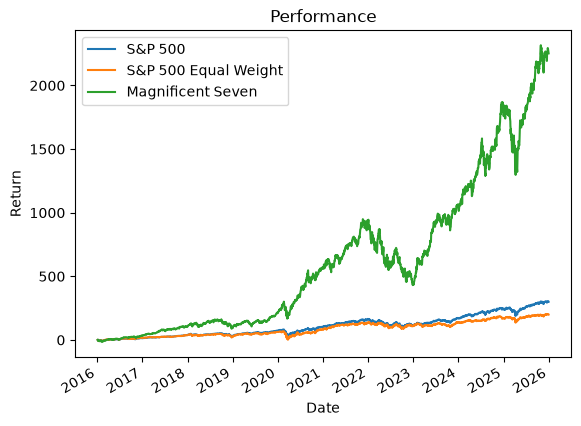

,Compounded return,Max drawdown
S&P 500,300.25%,-33.72%
S&P 500 Equal Weight,199.60%,-39.04%
Magnificent Seven,2251.74%,-49.38%


In [66]:
performance = pd.DataFrame({
    "Compounded return": ((1 + every_daily_simple_return).prod() - 1),
})

(((1 + every_daily_simple_return).cumprod() - 1) * 100).plot(
    title="Performance", ylabel="Return"
)
plt.show()
plt.close()

pd.concat([performance, max_drawdown(every_daily_simple_return)], axis=1).style.format(
    "{:.2%}"
)

The Magnificent Seven gained $2{,}251.74\%$ over the past ten years, far ahead of SPY and RSP. It also has the biggest maximum drawdown of the three. RSP fell further because its equal weight gives more room to smaller, more cyclical names, which dropped harder and recovered more slowly than the mega-caps that dominate SPY.

## 8. Herfindahl-Hirschman Index and effective diversification

The Herfindahl-Hirschman Index (HHI) and the Effective Number of Constituents (ENC) summarize how concentrated an index is in a single number. They are two views of the same quantity: the HHI measures concentration directly, while the ENC rescales it into the number of equal-sized constituents the index behaves like.

Let $s_i$ be the weight of constituent $i$ in a portfolio of $n$ assets, with $\sum_{i=1}^n s_i = 1$.

Herfindahl-Hirschman Index:

$$\text{HHI} = \sum_{i=1}^n s_i^2$$

*On the standard $0$ to $10{,}000$ scale (weights in percentage points), HHI is bounded between $\frac{10{,}000}{n}$ (equal weights) and $10{,}000$ (one dominant constituent).*

The Effective Number of Constituents:

$$\text{ENC} = \frac{1}{\text{HHI}} = \left( \sum_{i=1}^n s_i^2 \right)^{-1}$$

In [67]:
sp_500_weights = pd.read_excel("data/raw/holdings-daily-us-en-spy.xlsx", skiprows=4)
sp_500_weights = sp_500_weights[["Ticker", "Weight"]].dropna()
sp_500_weights["Weight"] /= 100

In [68]:
hhi(sp_500_weights).style.format("{:.2f}")

,Value
HHI,208.92
ENC,47.86


A low ENC relative to $n$ is the signature of concentration: the portfolio is driven by a handful of names despite holding hundreds. This is the quantitative core of our thesis: the S&P 500 holds $n = 500$ stocks but, as computed below, its $\text{ENC} \approx 48$, meaning it behaves like a portfolio of only about 48 equal-weighted names.

Parsing the official State Street SPDR S&P 500 ETF holdings file (as of August 25, 2026):

*The weights are a point-in-time snapshot. We use the most recent file because section 8 is about the current structure of the index, not its historical path.*

- Empirical HHI: $208.92$ (out of $10{,}000$).
- Effective number of constituents: $\text{ENC} \approx 47.86$.

Under a perfectly equal-weighted index, the ENC would equal the physical constituent count:

$$\text{ENC}_{RSP} = 500$$

The actual cap-weighted S&P 500:

$$\text{ENC}_{SPY} \approx 47.86$$

In other words, while the S&P 500 holds 500 companies on paper, its concentration in a handful of top constituents (Nvidia, Apple, Microsoft, Amazon among them) means it behaves like an equally weighted portfolio of roughly 48 stocks. For an investor who wants broad structural diversification, the cap-weighted index does not deliver what its name implies. The equal-weighted version comes considerably closer.

## 9. Conclusion

The S&P 500 looks like 500 companies, but it behaves like about 48. Its effective number of constituents is $47.86$, against the 500 it claims to hold. The concentration is not a rounding error: a handful of mega-cap technology firms now carry the index's return.

The returns tell the same story from the other side. Over ten years the Magnificent Seven returned $2{,}251.74\%$, dwarfing the cap-weighted and equal-weighted indices, but with the deepest drawdown of the three ($-49.38\%$). The S&P 500's smaller drawdown ($-33.72\%$) than the equal-weighted version ($-39.04\%$) is not a sign of safety.

The risk-adjusted picture is the same. The S&P 500 posts a higher Sharpe than the equal-weighted index, and the Magnificent Seven the highest of all three, not because concentration is safer but because its returns were strong enough to outrun the risk it added. Normality does not describe these series either: fat tails and excess kurtosis mean volatility alone understates the real danger.

For an investor who wants broad diversification, the cap-weighted S&P 500 does not deliver what its name suggests. The equal-weighted version comes closer: with nearly equal weights by construction, its effective number of constituents stays close to the full 500. The cap-weighted index behaves like roughly 48. The breadth is real on paper, but in practice the index behaves like a much smaller one.